In [2]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-08-llm-from-scratch


# Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.model.llm import LLM
from src.training.trainer import LLMTrainer

# Terminal STDOut
![MoE snapshot](dense_default_terminal_stdout.png)

# Load artifacts

In [4]:
best_ckpt_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_09_04_04_33_04/best.pt'
train_log_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/logs/2026_09_04_04_33_04/train.log'

best_ckpt = torch.load(best_ckpt_path, map_location='cpu', weights_only=False)

# Plot Losses

In [5]:
best_ckpt.keys()

dict_keys(['model_state_dict', 'optimizer_state_dict', 'model_config', 'train_config', 'step', 'train_loss_hist', 'val_loss_hist', 'train_loader_state', 'rng_state'])

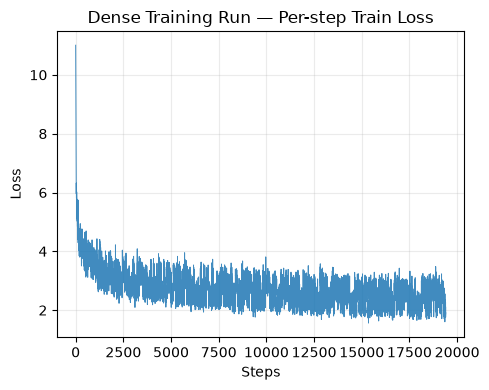

In [6]:
# Train Loss @ every step
train_loss = best_ckpt['train_loss_hist']
steps = np.arange(len(train_loss))
best_val = min(best_ckpt['val_loss_hist'])

plt.figure(figsize=(5, 4))
plt.plot(steps, train_loss, linewidth=0.7, alpha=0.85)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Dense Training Run — Per-step Train Loss')

plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [7]:
# Best Val loss found just before 20k steps
print(f"{'train_loss_length':20s}: {len(best_ckpt['train_loss_hist'])}")
print(f"{'val_loss_length':20s}: {len(best_ckpt['val_loss_hist'])}")

train_loss_length   : 19401
val_loss_length     : 98


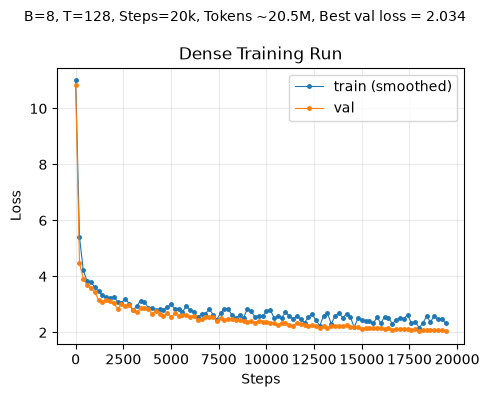

In [8]:
# Get steps
EVAL_INTERVAL = best_ckpt['train_config'].eval_interval
steps = np.arange(len(best_ckpt['val_loss_hist'])) * EVAL_INTERVAL

# Smooth train loss over steps
train_loss_smoothed = np.array(best_ckpt['train_loss_hist'][1:]).reshape(len(steps) - 1, -1).mean(axis=-1)
train_loss_smoothed = np.concatenate([[best_ckpt['train_loss_hist'][0]], train_loss_smoothed])

# Get best val loss
best_val = min(best_ckpt['val_loss_hist'])

# Plot train and val loss over steps
plt.figure(figsize=(5, 4))
plt.plot(steps, train_loss_smoothed, label='train (smoothed)', marker='o', markersize=2.5, linewidth=0.8)
plt.plot(steps, best_ckpt['val_loss_hist'], label='val', marker='o', markersize=2.5, linewidth=0.8)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Dense Training Run')
plt.suptitle('B=8, T=128, Steps=20k, Tokens ~20.5M, Best val loss = {:.3f}'.format(best_val), y=0.98, fontsize=10)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot LR Schedule

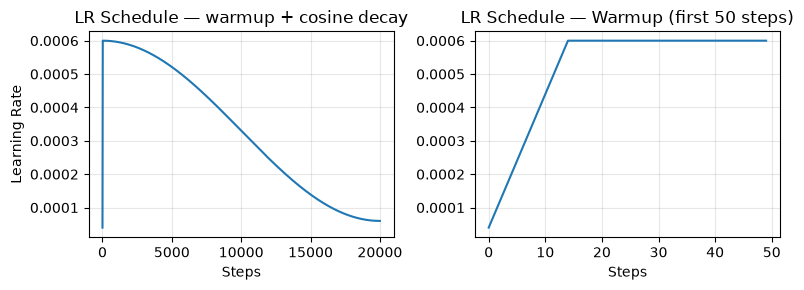

In [9]:
# This is the LR schedule defined in the trainer.py file
def get_lr(step, init_lr, final_lr, max_step, warmup_steps):
    warmup_steps_reslv = min(warmup_steps, int(0.05 * max_step))
    if step < warmup_steps_reslv:
        return init_lr * ((step + 1) / warmup_steps_reslv)
    cosine = 0.5 * (np.cos((np.pi / (max_step - warmup_steps_reslv)) * (step - warmup_steps_reslv)) + 1)
    return (init_lr - final_lr) * cosine + final_lr

tc = best_ckpt['train_config']
steps = np.arange(tc.num_steps)
lrs = [get_lr(s, tc.learning_rate, tc.min_lr, tc.num_steps, tc.warmup_steps) for s in steps]

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(steps, lrs)
plt.xlabel('Steps'); plt.ylabel('Learning Rate')
plt.title('LR Schedule — warmup + cosine decay')
plt.grid(alpha=0.3)
plt.tight_layout(); 


plt.subplot(1, 2, 2)
plt.plot(steps[:50], lrs[:50])
plt.xlabel('Steps'); #plt.ylabel('Learning Rate')
plt.title('LR Schedule — Warmup (first 50 steps)')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Plot Grad Norm and Training TPUT

In [10]:
steps, tputs, grad_norms = [], [], []

# Parse train.log file
with open(train_log_path, 'r') as f:
    log_data = f.readlines()
    for line in log_data:
        if not line.startswith('Step'):
            continue

        parts = line.split(', ')
        steps.append(int(parts[0].split(': ')[1]))
        tputs.append(float(parts[2].split(': ')[1].split()[0]))
        grad_norms.append(float(parts[4].split(': ')[1]))

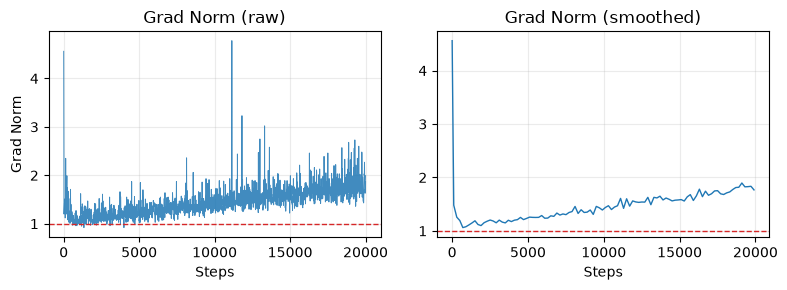

In [11]:
# Plot Grad Norm
window = 20

grad_smooth = np.array(grad_norms[1:]).reshape(-1, window).mean(axis=-1)
grad_smooth = np.concatenate([[grad_norms[0]], grad_smooth])

smooth_steps = np.array(steps[1:]).reshape(-1, window).mean(axis=-1)
smooth_steps = np.concatenate([[steps[0]], smooth_steps])

max_grad_clip = best_ckpt['train_config'].grad_clip

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(steps, grad_norms, linewidth=0.7, alpha=0.85)
plt.axhline(max_grad_clip, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Grad Norm')
plt.title('Grad Norm (raw)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.subplot(1, 2, 2)
plt.plot(smooth_steps, grad_smooth, linewidth=1.0)
plt.axhline(max_grad_clip, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps')
plt.title('Grad Norm (smoothed)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

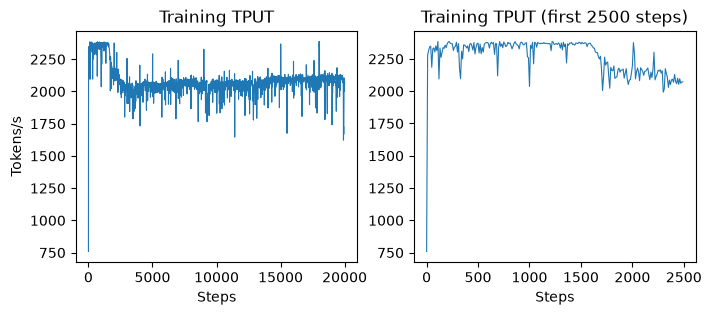

In [12]:
# Plot TPUT
LOG_INTERVAL = best_ckpt['train_config'].log_interval

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(steps, tputs, label='TPUT', linewidth=0.8)
plt.xlabel('Steps')
plt.ylabel('Tokens/s')
plt.title('Training TPUT')

plt.subplot(1, 2, 2)
init_steps = 250
plt.plot(steps[:init_steps], tputs[:init_steps], linewidth=0.8)
plt.xlabel('Steps')
# plt.ylabel('Tokens/s')
plt.title(f'Training TPUT (first {LOG_INTERVAL * init_steps} steps)')

plt.show()